In [1]:
!gdown 1SFWQ7Zi83Gff-RVrlHj0z4Llm1Nq4BBA

Downloading...
From: https://drive.google.com/uc?id=1SFWQ7Zi83Gff-RVrlHj0z4Llm1Nq4BBA
To: /content/titanic_modified_dataset.csv
100% 25.9k/25.9k [00:00<00:00, 37.6MB/s]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# prompt: read csv titaniic

import pandas as pd

df = pd.read_csv('titanic_modified_dataset.csv', index_col ='PassengerId')
print(df.head())


             Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Title  \
PassengerId                                                              
1                 3    0  22.0      1      0   7.2500         0      0   
2                 1    1  38.0      1      0  71.2833         1      1   
3                 3    1  26.0      0      0   7.9250         0      2   
4                 1    1  35.0      1      0  53.1000         0      1   
5                 3    0  35.0      0      0   8.0500         0      0   

             Survived  
PassengerId            
1                   0  
2                   1  
3                   1  
4                   1  
5                   0  


In [4]:
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

In [5]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), 1)
X_b

array([[ 1.    ,  3.    ,  0.    , ...,  7.25  ,  0.    ,  0.    ],
       [ 1.    ,  1.    ,  1.    , ..., 71.2833,  1.    ,  1.    ],
       [ 1.    ,  3.    ,  1.    , ...,  7.925 ,  0.    ,  2.    ],
       ...,
       [ 1.    ,  3.    ,  1.    , ..., 23.45  ,  0.    ,  2.    ],
       [ 1.    ,  1.    ,  0.    , ..., 30.    ,  1.    ,  0.    ],
       [ 1.    ,  3.    ,  0.    , ...,  7.75  ,  2.    ,  0.    ]])

In [6]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train , X_val , y_train , y_val = train_test_split(
    X_b , y,
    test_size = val_size ,
    random_state = random_state ,
    shuffle = is_shuffle
)

X_train , X_test , y_train , y_test = train_test_split(
    X_train , y_train ,
    test_size = test_size ,
    random_state = random_state ,
    shuffle = is_shuffle
)

In [7]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [8]:
def predict (X, theta ) :
    dot_product = np.dot(X, theta)
    y_hat = sigmoid(dot_product)

    return y_hat

def sigmoid(z):
    return 1/(1 + np.exp(-z) )

def compute_loss(y_hat , y) :
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)

    return ( -y*np.log(y_hat) - (1 - y)*np.log(1 - y_hat) ).mean()

def compute_gradient(X, y, y_hat ) :
    return np.dot( X.T, (y_hat - y) ) / y.size

def update_theta(theta, gradient, lr):
    return theta - lr*gradient

def compute_accuracy(X, y, theta):
    y_hat = predict(X, theta).round()
    acc = (y_hat == y).mean()

    return acc

In [9]:
lr = 0.01
epochs = 100
batch_size = 16
np. random.seed( random_state )
theta = np. random.uniform (
    size = X_train.shape [1]
)

In [10]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []
for epoch in range( epochs ):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size ) :
        X_i = X_train [i:i+ batch_size ]
        y_i = y_train [i:i+ batch_size ]

        y_hat = predict (X_i, theta )

        train_loss = compute_loss (y_hat, y_i )

        gradient = compute_gradient (X_i, y_i, y_hat )

        theta = update_theta (theta, gradient, lr)


        train_batch_losses.append( train_loss )

        train_acc = compute_accuracy( X_train, y_train, theta )
        train_batch_accs.append( train_acc )

        y_val_hat = predict (X_val, theta )
        val_loss = compute_loss( y_val_hat, y_val )
        val_batch_losses.append( val_loss )

        val_acc = compute_accuracy (X_val, y_val, theta )
        val_batch_accs.append( val_acc )

    train_batch_loss = sum( train_batch_losses ) / len(train_batch_losses)
    val_batch_loss = sum( val_batch_losses ) / len( val_batch_losses )
    train_batch_acc = sum( train_batch_accs ) / len( train_batch_accs )
    val_batch_acc = sum( val_batch_accs ) / len( val_batch_accs )

    train_losses.append( train_batch_loss )
    val_losses.append( val_batch_loss )
    train_accs.append( train_batch_acc )
    val_accs.append( val_batch_acc )

    print(f'\n EPOCH { epoch + 1}:\t Training loss : { train_batch_loss:.3f}\t Validation loss : { val_batch_loss:.3f}')


 EPOCH 1:	 Training loss : 0.703	 Validation loss : 0.599

 EPOCH 2:	 Training loss : 0.670	 Validation loss : 0.582

 EPOCH 3:	 Training loss : 0.640	 Validation loss : 0.567

 EPOCH 4:	 Training loss : 0.614	 Validation loss : 0.555

 EPOCH 5:	 Training loss : 0.592	 Validation loss : 0.544

 EPOCH 6:	 Training loss : 0.572	 Validation loss : 0.535

 EPOCH 7:	 Training loss : 0.554	 Validation loss : 0.528

 EPOCH 8:	 Training loss : 0.539	 Validation loss : 0.522

 EPOCH 9:	 Training loss : 0.526	 Validation loss : 0.517

 EPOCH 10:	 Training loss : 0.514	 Validation loss : 0.513

 EPOCH 11:	 Training loss : 0.504	 Validation loss : 0.509

 EPOCH 12:	 Training loss : 0.495	 Validation loss : 0.507

 EPOCH 13:	 Training loss : 0.487	 Validation loss : 0.505

 EPOCH 14:	 Training loss : 0.480	 Validation loss : 0.503

 EPOCH 15:	 Training loss : 0.474	 Validation loss : 0.502

 EPOCH 16:	 Training loss : 0.468	 Validation loss : 0.501

 EPOCH 17:	 Training loss : 0.463	 Validation lo

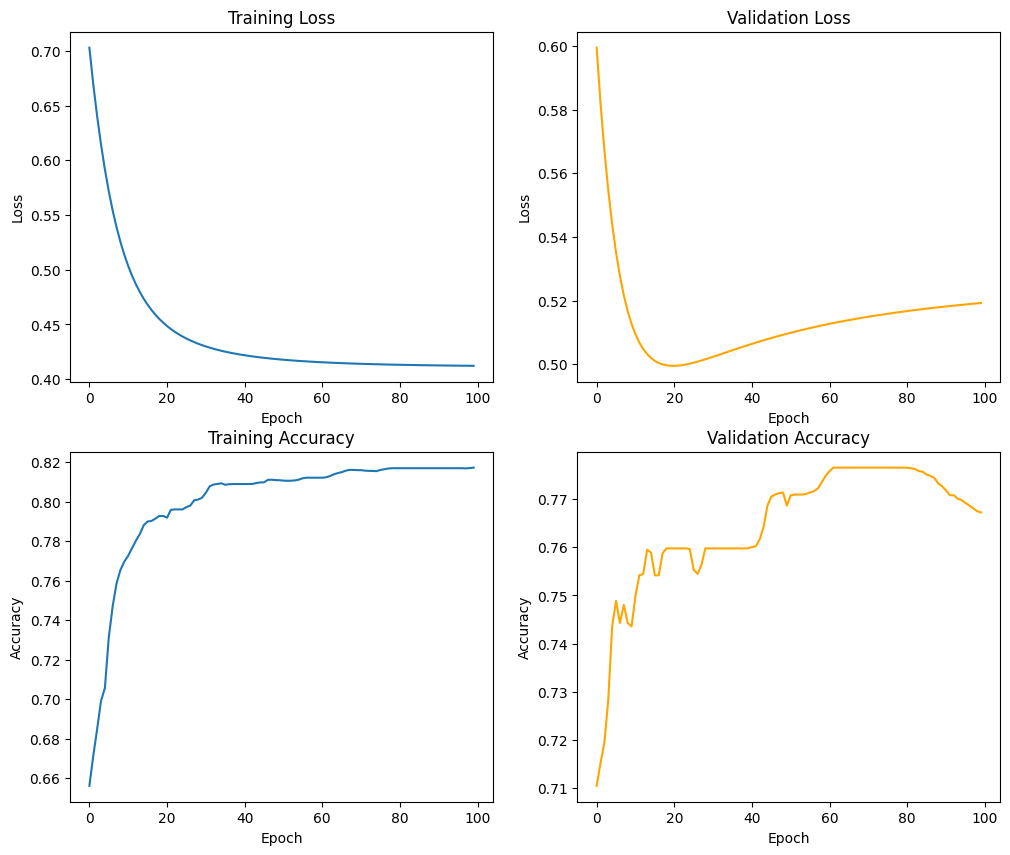

In [11]:
fig, ax = plt.subplots(2, 2, figsize =(12, 10) )
ax[0, 0].plot( train_losses )
ax[0, 0].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot( val_losses,'orange')
ax[0, 1].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot( train_accs )
ax[1, 0].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot( val_accs,'orange')
ax[1, 1].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

In [12]:
val_set_acc = compute_accuracy (X_val, y_val, theta )
test_set_acc = compute_accuracy ( X_test, y_test, theta )
print('Evaluation on validation and test set :')
print(f'Accuracy : { val_set_acc }')
print(f'Accuracy : { test_set_acc }')

Evaluation on validation and test set :
Accuracy : 0.770949720670391
Accuracy : 0.7752808988764045


In [13]:
import re
import nltk
from nltk.tokenize import TweetTokenizer
from collections import defaultdict

In [14]:
!gdown 1dANzxlEjeCEbveFOWWqzSG-niVx-vCgK

Downloading...
From: https://drive.google.com/uc?id=1dANzxlEjeCEbveFOWWqzSG-niVx-vCgK
To: /content/sentiment_analysis.csv
100% 1.10M/1.10M [00:00<00:00, 32.7MB/s]


In [15]:
df = pd.read_csv('sentiment_analysis.csv', index_col ='id')
print(df.head())

    label                                              tweet
id                                                          
1       0  #fingerprint #Pregnancy Test https://goo.gl/h1...
2       0  Finally a transparant silicon case ^^ Thanks t...
3       0  We love this! Would you go? #talk #makememorie...
4       0  I'm wired I know I'm George I was made that wa...
5       1  What amazing service! Apple won't even talk to...


In [16]:
def text_normalize( text ) :
    # Retweet old acronym "RT" removal
    text = re.sub(r'^RT [\s]+ ', '', text )

    # Hyperlinks removal
    text = re.sub(r'https ?:\/\/.*[\ r\n]* ', '', text )

    # Hashtags removal
    text = re.sub(r'#', '', text )

    # Punctuation removal
    text = re.sub(r'[^\ w\s]', '', text )

    # Tokenization
    tokenizer = TweetTokenizer(
        preserve_case =False ,
        strip_handles =True ,
        reduce_len = True
    )
    text_tokens = tokenizer.tokenize( text )

    return text_tokens

In [17]:
def get_freqs(df) :
    freqs = defaultdict( lambda : 0)
    for idx, row in df.iterrows() :
        tweet = row['tweet']
        label = row['label']

        tokens = text_normalize( tweet )
        for token in tokens :
            pair = (token, label )
            freqs[ pair ] += 1

    return freqs

In [18]:
def get_feature(text , freqs ) :
    tokens = text_normalize( text )

    X = np.zeros(3)
    X[0] = 1

    for token in tokens :
        X[1] += freqs[( token , 0) ]
        X[2] += freqs[( token , 1) ]

    return X

In [19]:
X = []
y = []
freqs = get_freqs(df)
for idx, row in df.iterrows():
    tweet = row['tweet']
    label = row['label']
    X_i = get_feature(tweet, freqs)
    X.append(X_i)
    y.append(label)

X = np.array(X)
y = np.array(y)

In [20]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train , X_val , y_train , y_val = train_test_split(
    X , y,
    test_size = val_size ,
    random_state = random_state ,
    shuffle = is_shuffle
)

X_train , X_test , y_train , y_test = train_test_split(
    X_train , y_train ,
    test_size = test_size ,
    random_state = random_state ,
    shuffle = is_shuffle
)

In [21]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

In [22]:
lr = 0.01
epochs = 100
batch_size = 16
np. random.seed( random_state )
theta = np. random.uniform (
    size = X_train.shape [1]
)

In [23]:
train_accs = []
train_losses = []
val_accs = []
val_losses = []
for epoch in range( epochs ):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train . shape [0], batch_size ) :
        X_i = X_train [i:i+ batch_size ]
        y_i = y_train [i:i+ batch_size ]

        y_hat = predict (X_i, theta )

        train_loss = compute_loss (y_hat, y_i )

        gradient = compute_gradient (X_i, y_i, y_hat )

        theta = update_theta (theta, gradient, lr)


        train_batch_losses.append( train_loss )

        train_acc = compute_accuracy( X_train, y_train, theta )
        train_batch_accs.append( train_acc )

        y_val_hat = predict (X_val, theta )
        val_loss = compute_loss( y_val_hat, y_val )
        val_batch_losses.append( val_loss )

        val_acc = compute_accuracy (X_val, y_val, theta )
        val_batch_accs.append( val_acc )

    train_batch_loss = sum( train_batch_losses ) / len(train_batch_losses)
    val_batch_loss = sum( val_batch_losses ) / len( val_batch_losses )
    train_batch_acc = sum( train_batch_accs ) / len( train_batch_accs )
    val_batch_acc = sum( val_batch_accs ) / len( val_batch_accs )

    train_losses.append( train_batch_loss )
    val_losses.append( val_batch_loss )
    train_accs.append( train_batch_acc )
    val_accs.append( val_batch_acc )

    print(f'\n EPOCH { epoch + 1}:\t Training loss : { train_batch_loss:.3f}\t Validation loss : { val_batch_loss:.3f}')


 EPOCH 1:	 Training loss : 0.708	 Validation loss : 0.706

 EPOCH 2:	 Training loss : 0.593	 Validation loss : 0.596

 EPOCH 3:	 Training loss : 0.573	 Validation loss : 0.577

 EPOCH 4:	 Training loss : 0.569	 Validation loss : 0.573

 EPOCH 5:	 Training loss : 0.568	 Validation loss : 0.573

 EPOCH 6:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 7:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 8:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 9:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 10:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 11:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 12:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 13:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 14:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 15:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 16:	 Training loss : 0.567	 Validation loss : 0.573

 EPOCH 17:	 Training loss : 0.567	 Validation lo

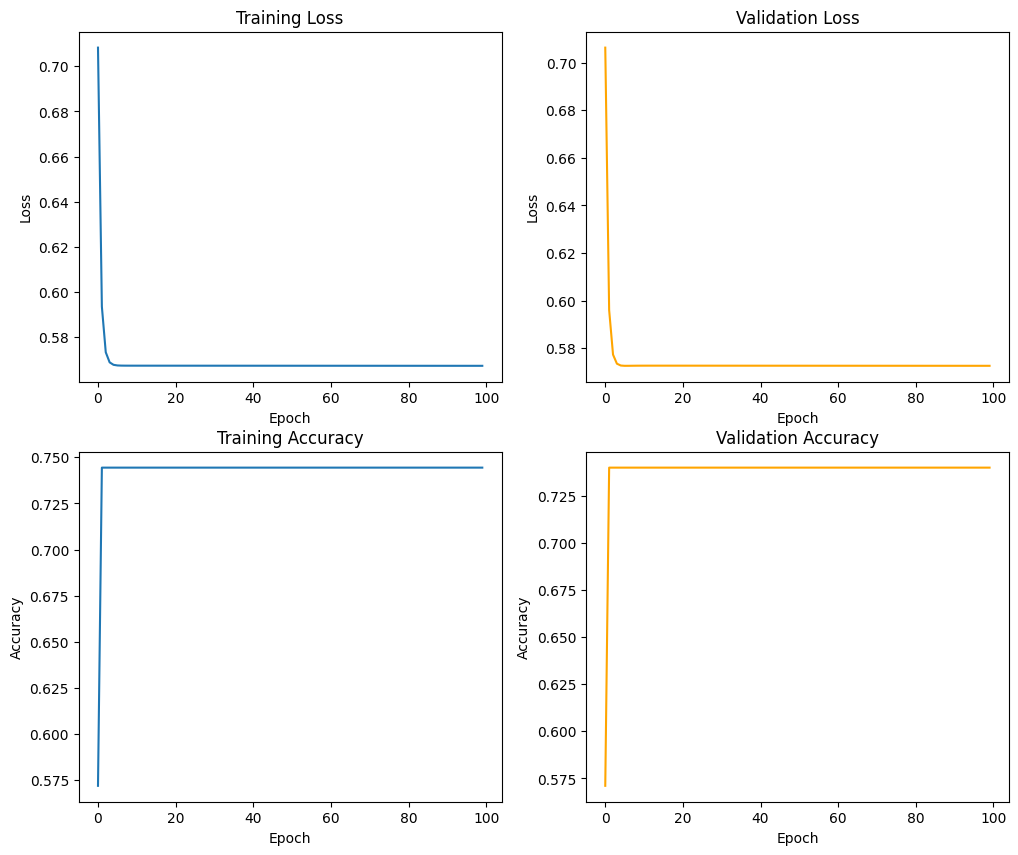

In [24]:
fig, ax = plt.subplots(2, 2, figsize =(12, 10) )
ax[0, 0].plot( train_losses )
ax[0, 0].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot( val_losses,'orange')
ax[0, 1].set( xlabel ='Epoch', ylabel ='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot( train_accs )
ax[1, 0].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot( val_accs,'orange')
ax[1, 1].set( xlabel ='Epoch', ylabel ='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

In [25]:
val_set_acc = compute_accuracy (X_val, y_val, theta )
test_set_acc = compute_accuracy ( X_test, y_test, theta )
print('Evaluation on validation and test set :')
print(f'Accuracy : { val_set_acc }')
print(f'Accuracy : { test_set_acc }')

Evaluation on validation and test set :
Accuracy : 0.73989898989899
Accuracy : 0.7512626262626263
